<a href="https://colab.research.google.com/github/nusukhan/palm-tree-counter/blob/main/palm_tree_counter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌴 Palm Tree Counter — Project Notes

## Step 1: GPU Check
Command checks if a GPU is available.
GPU makes training much faster.

In [ ]:
!nvidia-smi

Mon Sep 21 10:25:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Download Dataset (Roboflow)
Downloaded a ready-made palm tree dataset in YOLO format.
YOLO format = each image has a matching label file.

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="tt3LO2g24iGGdbzmh4SA")
project = rf.workspace("saluman").project("palm-tree-vacdh-r0ekl")
dataset = project.version(1).download("yolov8")
print(dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to palm-tree-1 in yolov8:: 100%|██████████| 52647/52647 [00:15<00:00, 3344.97it/s]


/content/palm-tree-1



## Step 3: Check Dataset Structure
See what is inside the dataset folder.
Found: train, valid, test folders + data.yaml file.

In [ ]:
!ls /content/palm-tree-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


## Step 4: Read data.yaml
This file tells YOLO where the data is and how many classes.
nc: 1 = only one class (palm tree).

In [ ]:
!cat /content/palm-tree-1/data.yaml

names:
- '0'
nc: 1
roboflow:
  license: CC BY 4.0
  project: palm-tree-vacdh-r0ekl
  url: https://universe.roboflow.com/saluman/palm-tree-vacdh-r0ekl/dataset/1
  version: 1
  workspace: saluman
test: ../test/images
train: ../train/images
val: ../valid/images


## Step 5: Check Train Folder
Look inside the train folder.
Found 2 folders: images (the pictures) + labels (the markings).

In [ ]:
!ls /content/palm-tree-1/train

images	labels


## Step 6: Look Inside a Label File
Open one label file to see how a tree is marked.
KEY LESSON: each line = one tree.
5 numbers per line = class + box location (center-x, center-y, width, height).

In [ ]:
!ls /content/palm-tree-1/train/labels | head -3

000000000002_png_jpg.rf.277bfc64b9ab7a6b7489662070f8897f.txt
000000000002_png_jpg.rf.f40d5209172d35ee8191bb5ab9ee5732.txt
000000000003_png_jpg.rf.0d9b343b3f68c8c54caeda1e7ffc1211.txt


## Step 7: Open a Label File to Count Lines
Read one label file with cat.
Each line = one tree, so number of lines = number of trees in that image.

In [ ]:
!cat /content/palm-tree-1/train/labels/000000000002_png_jpg.rf.277bfc64b9ab7a6b7489662070f8897f.txt

0 0.12109375 0.8578125 0.2421875 0.284375
0 0.11640625 0.5390625 0.2328125 0.3875
0 0.10625 0.18671875 0.2125 0.3734375
0 0.41953125 0.65546875 0.390625 0.440625
0 0.44453125 0.29765625 0.4859375 0.496875
0 0.7578125 0.86328125 0.484375 0.2734375
0 0.784375 0.51953125 0.43125 0.415625
0 0.79296875 0.17578125 0.4140625 0.3515625

# 🚀 Part 2: Training

## Step 8: Install YOLO (ultralytics)
YOLO is a ready-made model that detects objects with boxes.
We use it instead of building a model from scratch (transfer learning).
ultralytics is the library that gives us YOLO.

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 8.3 MB/s eta 0:00:00


## Part 3: Test the Model on an Image

Before running on video, we test the trained model on a **single test
image** (one it never saw during training). This shows how the model
draws boxes and counts palm trees.

- We take one image from the **test** folder
- The model predicts and draws a box on each detected tree
- `len(results[0].boxes)` gives the total tree count for that image

This is a quick check that the model works correctly on unseen images.

Trees detected: 94


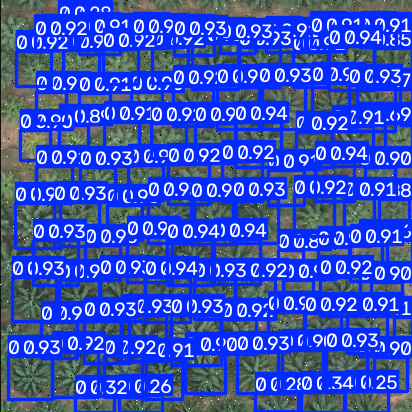

In [ ]:
from google.colab.patches import cv2_imshow
import os

test_folder = "/content/palm-tree-1/test/images"
first_image = os.listdir(test_folder)[0]
image_path = os.path.join(test_folder, first_image)

results = model.predict(image_path, conf=0.25, verbose=False)
print("Trees detected:", len(results[0].boxes))
cv2_imshow(results[0].plot())

## Step 9: Load the YOLO Model
Load a small pre-trained YOLO model (yolo26n = nano = smallest, fastest).
"Pre-trained" means it already learned from millions of images.
We will teach it palm trees on top of that (transfer learning)..

In [ ]:
from ultralytics import YOLO
model26 = YOLO("yolo26n.pt")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
!ls /content/palm-tree-1

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid


In [ ]:
!pip install ultralytics
from google.colab import drive
drive.mount('/content/drive')

from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/palm_tree_model/train/weights/best.pt")
print("Model loaded:", "model" in dir())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 11.4 MB/s eta 0:00:00
Mounted at /content/drive
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Model loaded: True


## Part 4: Video Tree Detection (OpenCV Frame-by-Frame)

We load our trained model and run it on a drone video, processing it
**frame by frame** with OpenCV.

**Steps:**
1. `cv2.VideoCapture` opens the input video
2. `cv2.VideoWriter` creates a new output video for the boxes
3. A `while` loop reads each frame one by one
4. The model detects and counts palm trees in every frame
5. The count is written on the frame with `cv2.putText`
6. `max_trees` tracks the highest count seen in any single frame
7. The annotated video is saved when all frames are done

- **conf=0.25:** draw a box only when 25%+ confident
- **Note:** 4K video on CPU, so it runs slowly — this is normal

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

video_address = "/content/video.mp4"
output_path = "/content/output_tree_detection.mp4"

video = cv2.VideoCapture(video_address)
fps = video.get(cv2.CAP_PROP_FPS)
width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

frame_count = 0
max_trees = 0

while True:
    ret, frame = video.read()
    if not ret:
        break

    result = model.predict(frame, conf=0.25, verbose=False)
    annotated_frame = result[0].plot()
    tree_count = len(result[0].boxes)
    max_trees = max(max_trees, tree_count)

    cv2.putText(annotated_frame, f"Trees: {tree_count}", (30, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)
    writer.write(annotated_frame)

    if frame_count % 30 == 0:
        print(f"Frame {frame_count}: {tree_count} trees")
    frame_count += 1

video.release()
writer.release()
print(f"\nDone. Processed {frame_count} frames.")
print(f"Max trees in a single frame: {max_trees}")
print(f"Saved to: {output_path}")

Frame 0: 25 trees
Frame 30: 28 trees
Frame 60: 25 trees
Frame 90: 22 trees
Frame 120: 22 trees
Frame 150: 23 trees
Frame 180: 27 trees
Frame 210: 25 trees
Frame 240: 25 trees
Frame 270: 24 trees
Frame 300: 26 trees
Frame 330: 28 trees
Frame 360: 27 trees
Frame 390: 27 trees
Frame 420: 28 trees
Frame 450: 31 trees
Frame 480: 28 trees
Frame 510: 21 trees
Frame 540: 24 trees
Frame 570: 26 trees
Frame 600: 22 trees
Frame 630: 23 trees
Frame 660: 25 trees
Frame 690: 26 trees
Frame 720: 29 trees
Frame 750: 29 trees
Frame 780: 34 trees
Frame 810: 32 trees

Done. Processed 817 frames.
Max trees in a single frame: 38
Saved to: /content/output_tree_detection.mp4


In [ ]:
from google.colab.patches import cv2_imshow

Trees in this frame: 26


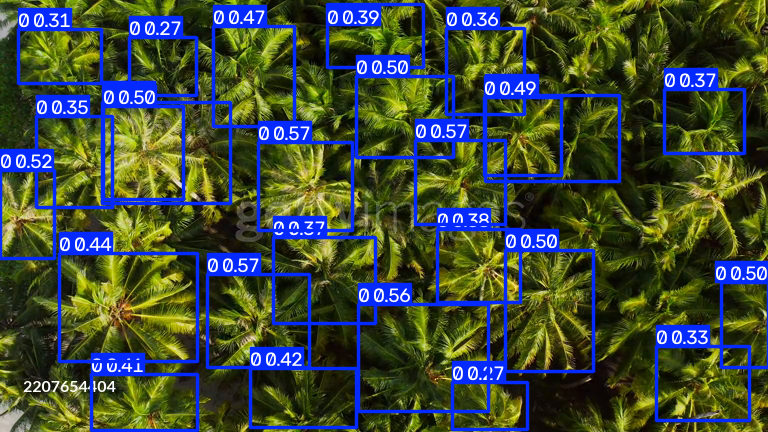

In [ ]:
video2 = cv2.VideoCapture("/content/video.mp4")
video2.set(cv2.CAP_PROP_POS_FRAMES, 300)
ret, frame = video2.read()
video2.release()

result = model.predict(frame, conf=0.25, verbose=False)
print("Trees in this frame:", len(result[0].boxes))
cv2_imshow(result[0].plot())

### Step: Play the Annotated Video

Finally, we play the output video (with detection boxes and the tree
count) directly inside the notebook.

- The video is read and embedded using `IPython.display.HTML`
- Press the play button to watch the palm-tree detection in action
- Each frame shows blue boxes on detected trees and a live "Trees: N" count

Note: this is a 4K video, so it may take a moment to load in the browser.

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_file = "/content/output_tree_detection.mp4"
mp4 = open(video_file, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

In [ ]:
import shutil
shutil.copy("/content/output_tree_detection.mp4", "/content/drive/MyDrive/output_tree_detection.mp4")
print("Copied to Drive")

Copied to Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
